# Сравнение моделей

## 1. Data


In [1]:
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

train = pd.read_parquet("../data/processed/train.parquet")
val = pd.read_parquet("../data/processed/validation.parquet")

print("Train:", train.shape)
print("Validation:", val.shape)

print("Train target:", train["is_canceled"].mean())
print("Validation target:", val["is_canceled"].mean())


Train: (82629, 38)
Validation: (18065, 38)
Train target: 0.380108678551114
Validation target: 0.3928037641848879


In [2]:
target = "is_canceled"

drop_cols = [
    target,
    "booking_date",
    "arrival_date"
]

X_train = train.drop(columns=drop_cols)
y_train = train[target]

X_val = val.drop(columns=drop_cols)
y_val = val[target]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

(82629, 35) (82629,)
(18065, 35) (18065,)


In [3]:
categorical_cols = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_cols = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical:", len(categorical_cols))
print(categorical_cols)

print("\nNumeric:", len(numeric_cols))
print(numeric_cols)

Categorical: 12
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'agent', 'company', 'customer_type', 'country_group']

Numeric: 23
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'has_children', 'has_agent', 'has_company', 'has_agent_or_company', 'total_guests', 'total_nights', 'has_previous_cancellation', 'is_zero_adr']


In [4]:
for col in categorical_cols:
    X_train[col] = (
        X_train[col]
        .astype("object")
        .where(X_train[col].notna(), np.nan)
    )

    X_val[col] = (
        X_val[col]
        .astype("object")
        .where(X_val[col].notna(), np.nan)
    )

## 2. Preprocessing


In [5]:
numeric_pipeline = Pipeline([
    (
        'imputer', SimpleImputer(strategy='median')
     ),
    (
        'scaler', StandardScaler()
    ),
])

In [6]:
cat_pipeline = Pipeline([
    (
        'imputer', SimpleImputer(
            strategy='constant',
            fill_value='missing'
        )
    ),
    (
        'encoder', OneHotEncoder(
            handle_unknown='ignore'
        )
    ),
])

In [7]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', cat_pipeline, categorical_cols)
])

Функция для оценки:


In [8]:
def evaluate_model(model, X, y):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]

    return {
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "roc_auc": roc_auc_score(y, proba),
        "pr_auc": average_precision_score(y, proba)
    }

## 3. Baseline


### 3.1 Dummy classifier


In [9]:
dummy = DummyClassifier(strategy="prior")

dummy.fit(X_train, y_train)

dummy_results = evaluate_model(
    dummy,
    X_val,
    y_val
)

dummy_results


{'accuracy': 0.6071962358151121,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': 0.5,
 'pr_auc': 0.3928037641848879}

## 4. Logistic Regression


### 4.1 Обучаем log reg


In [10]:
logreg = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000
        )
    )
])

In [11]:
logreg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](35,)","['hotel','lead_time','arrival_date_year',...,'total_nights', 'has_previous_cancellation','is_zero_adr']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,35
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [12]:
logreg_results = evaluate_model(
    logreg,
    X_val,
    y_val
)

logreg_results

{'accuracy': 0.8021588707445336,
 'precision': 0.7189209348582795,
 'recall': 0.8149661781285231,
 'f1': 0.7639365918097755,
 'roc_auc': 0.8955512039001374,
 'pr_auc': 0.864041379055705}

In [13]:
results = pd.DataFrame([
    {
        "model": "DummyClassifier",
        **dummy_results
    },
    {
        "model": "LogisticRegression",
        **logreg_results
    }
])

results.set_index("model").round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
DummyClassifier,0.6072,0.0000,0.000,0.0000,0.5000,0.3928
LogisticRegression,0.8022,0.7189,0.815,0.7639,0.8956,0.8640


### Вывод
`Logistic Regression` уже даёт хороший `baseline`. `ROC-AUC` = 0.878 и `PR-AUC` = 0.851 значительно выше `DummyClassifier`. При стандартном `пороге 0.5` модель находит около `76% отмен` при `precision около 72%`. Значит даже простая линейная модель уже хорошо использует информацию в признаках.


### 4.2 Смотрим где наша модель делала ошибки


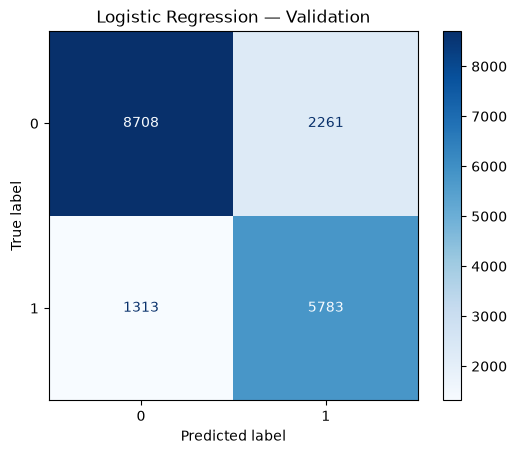

In [14]:
ConfusionMatrixDisplay.from_estimator(
    logreg,
    X_val,
    y_val,
    cmap="Blues"
)

plt.title("Logistic Regression — Validation")
plt.show()


При пороге 0.5 модель допускает `1680 FN` и `2118 FP`. Для работы менеджеров особенно важны ложные срабатывания: если их слишком много, список рискованных броней перестанет быть полезным. Поэтому после выбора модели зафиксирую `Precision >= 0.70`, а затем постараюсь получить максимально возможный `Recall`.

## 5. Tree models


### 5.1 Decision tree


In [15]:
decision_tree = Pipeline([
    ("preprocessor", clone(preprocessor)),
    (
        "model",
        DecisionTreeClassifier(
            random_state=42,
            max_depth= 8,
            min_samples_leaf= 50,
        )
    )
])

decision_tree.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](35,)","['hotel','lead_time','arrival_date_year',...,'total_nights', 'has_previous_cancellation','is_zero_adr']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,35
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [16]:
tree_train_results = evaluate_model(
    decision_tree,
    X_train,
    y_train
)

tree_val_results = evaluate_model(
    decision_tree,
    X_val,
    y_val
)

pd.DataFrame([
    {"split": "train", **tree_train_results},
    {"split": "validation", **tree_val_results},
]).set_index("split").round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
split,,,,,,
train,0.8538,0.8141,0.7974,0.8057,0.9265,0.8845
validation,0.7509,0.6251,0.9140,0.7424,0.8896,0.8236


### 5.2 Random Forest


In [17]:
random_forest = Pipeline([
    ("preprocessor", clone(preprocessor)),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=42
        )
    )
])

random_forest.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](35,)","['hotel','lead_time','arrival_date_year',...,'total_nights', 'has_previous_cancellation','is_zero_adr']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,35
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [18]:
rf_train_results = evaluate_model(
    random_forest,
    X_train,
    y_train
)

rf_val_results = evaluate_model(
    random_forest,
    X_val,
    y_val
)

pd.DataFrame([
    {"split": "train", **rf_train_results},
    {"split": "validation", **rf_val_results},
]).set_index("split").round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
split,,,,,,
train,0.8487,0.9467,0.6379,0.7622,0.9436,0.9242
validation,0.8107,0.8848,0.5955,0.7119,0.9053,0.8790


Сравним все модели в одной таблице


In [19]:
results = pd.DataFrame([
    {
        "model": "DummyClassifier",
        **dummy_results
    },
    {
        "model": "LogisticRegression",
        **logreg_results
    },
    {
        "model": "DecisionTree",
        **tree_val_results
    },
    {
        "model": "RandomForest",
        **rf_val_results
    }
])

results.set_index("model").round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
DummyClassifier,0.6072,0.0000,0.0000,0.0000,0.5000,0.3928
LogisticRegression,0.8022,0.7189,0.8150,0.7639,0.8956,0.8640
DecisionTree,0.7509,0.6251,0.9140,0.7424,0.8896,0.8236
RandomForest,0.8107,0.8848,0.5955,0.7119,0.9053,0.8790


Вывод: `Decision Tree` лучше всего находит отмены — `Recall` = 0.90, но при этом имеет низкий `Precision` = 0.63 и создаёт много ложных срабатываний. `Random Forest` показывает лучшее общее качество: максимальные `ROC-AUC`, `PR-AUC`, `F1` и `Precision`. Для нашей задачи высокий `Recall` важен, но окончательное решение пока принять не можем


## 6. Boosting


## 6.1 CatBoost


### 6.1.1 Отдельные данные для catboost
Так как для catboost не нужны обработки категориальных признаков


In [20]:
X_train_cb = X_train.copy()
X_val_cb = X_val.copy()

In [21]:
cat_features = X_train_cb.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

cat_features

['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'deposit_type',
 'agent',
 'company',
 'customer_type',
 'country_group']

Заполняем пропуски в категориальных признаках и приводим к `str`. С пропусками в числовых признаках catboost умеет работать сам


In [22]:
for col in cat_features:
    X_train_cb[col] = (
        X_train_cb[col]
        .astype("string")
        .fillna("Missing")
    )

    X_val_cb[col] = (
        X_val_cb[col]
        .astype("string")
        .fillna("Missing")
    )

### 6.1.2 Обучаем модель


In [23]:
catboost_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=7,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)


In [24]:
catboost_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_features,
    eval_set=(X_val_cb, y_val),
    early_stopping_rounds=100,
    use_best_model=True
)

0:	test: 0.8653530	best: 0.8653530 (0)	total: 109ms	remaining: 1m 48s


100:	test: 0.9209703	best: 0.9209703 (100)	total: 3.74s	remaining: 33.3s


200:	test: 0.9235733	best: 0.9235733 (200)	total: 7.54s	remaining: 30s


300:	test: 0.9243341	best: 0.9244059 (292)	total: 11.4s	remaining: 26.4s


400:	test: 0.9246784	best: 0.9248276 (381)	total: 15.2s	remaining: 22.8s


500:	test: 0.9249779	best: 0.9250525 (489)	total: 19.2s	remaining: 19.2s


Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9250524667
bestIteration = 489

Shrink model to first 490 iterations.


CatBoostClassifier(depth=7, eval_metric='AUC', iterations=1000, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [25]:
catboost_results = evaluate_model(
    catboost_model,
    X_val_cb,
    y_val
)

catboost_results

{'accuracy': 0.8301134791032383,
 'precision': 0.7516560429946256,
 'recall': 0.8475197294250282,
 'f1': 0.7967145790554415,
 'roc_auc': 0.9250524667087312,
 'pr_auc': 0.8985035003824421}

In [26]:
catboost_train_results = evaluate_model(
    catboost_model,
    X_train_cb,
    y_train
)

pd.DataFrame([
    {"split": "train", **catboost_train_results},
    {"split": "validation", **catboost_results}
]).set_index("split").round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
split,,,,,,
train,0.9028,0.8905,0.8488,0.8691,0.9692,0.9555
validation,0.8301,0.7517,0.8475,0.7967,0.9251,0.8985


### 6.1.3 Сравнение с другими моделями


In [27]:
results = pd.DataFrame([
    {
        "model": "DummyClassifier",
        **dummy_results
    },
    {
        "model": "LogisticRegression",
        **logreg_results
    },
    {
        "model": "DecisionTree",
        **tree_val_results
    },
    {
        "model": "RandomForest",
        **rf_val_results
    },
    {
        "model": "CatBoost",
        **catboost_results
    }
])

results.set_index("model").round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
DummyClassifier,0.6072,0.0000,0.0000,0.0000,0.5000,0.3928
LogisticRegression,0.8022,0.7189,0.8150,0.7639,0.8956,0.8640
DecisionTree,0.7509,0.6251,0.9140,0.7424,0.8896,0.8236
RandomForest,0.8107,0.8848,0.5955,0.7119,0.9053,0.8790
CatBoost,0.8301,0.7517,0.8475,0.7967,0.9251,0.8985


### Вывод
`CatBoost` показывает лучшее качество среди текущих моделей. Он имеет максимальные `ROC-AUC` = 0.924 и `PR-AUC` = 0.897, поэтому лучше остальных ранжирует бронирования по риску отмены. При стандартном пороге 0.5 `Recall` уже достигает 0.835. Пока `CatBoost` — основной кандидат на финальную модель.


## 6.2 LightGBM


### 6.2.1 Готовим данные


In [28]:
boosting_preprocessor = clone(preprocessor)

X_train_enc = boosting_preprocessor.fit_transform(X_train)
X_val_enc = boosting_preprocessor.transform(X_val)

print(X_train_enc.shape)
print(X_val_enc.shape)


(82629, 801)
(18065, 801)


### 6.2.2 Обучаем модель


In [29]:
lightgbm_model = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)


In [30]:
lightgbm_model.fit(
    X_train_enc,
    y_train,
    eval_set=[(X_val_enc, y_val)],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(100),
        lgb.log_evaluation(100)
    ]
)

[LightGBM] [Info] Number of positive: 31408, number of negative: 51221
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009920 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1410
[LightGBM] [Info] Number of data points in the train set: 82629, number of used features: 327
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.380109 -> initscore=-0.489087
[LightGBM] [Info] Start training from score -0.489087
Training until validation scores don't improve for 100 rounds


/Users/kheichiev/projects/Hotel-cancellation/.venv/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[100]	valid_0's auc: 0.922263	valid_0's binary_logloss: 0.344156


[200]	valid_0's auc: 0.925292	valid_0's binary_logloss: 0.336025


[300]	valid_0's auc: 0.925379	valid_0's binary_logloss: 0.334972


Early stopping, best iteration is:
[258]	valid_0's auc: 0.925513	valid_0's binary_logloss: 0.335013


,learning_rate,0.05
,n_estimators,2000
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


### 6.2.3 Оценка


In [31]:
lightgbm_results = evaluate_model(
    lightgbm_model,
    X_val_enc,
    y_val
)

lightgbm_results

{'accuracy': 0.8326598394685857,
 'precision': 0.7566477630749843,
 'recall': 0.8461104847801578,
 'f1': 0.798882309892888,
 'roc_auc': 0.9255127098989537,
 'pr_auc': 0.8992704831344005}

In [32]:
lightgbm_train_results = evaluate_model(
    lightgbm_model,
    X_train_enc,
    y_train
)

pd.DataFrame([
    {"split": "train", **lightgbm_train_results},
    {"split": "validation", **lightgbm_results}
]).set_index("split").round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
split,,,,,,
train,0.8988,0.8856,0.8426,0.8635,0.9671,0.9528
validation,0.8327,0.7566,0.8461,0.7989,0.9255,0.8993


### 6.2.4 Сравниваем модели


In [33]:
results = pd.DataFrame([
    {"model": "DummyClassifier", **dummy_results},
    {"model": "LogisticRegression", **logreg_results},
    {"model": "DecisionTree", **tree_val_results},
    {"model": "RandomForest", **rf_val_results},
    {"model": "CatBoost", **catboost_results},
    {"model": "LightGBM", **lightgbm_results}
])

results.set_index("model").round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
DummyClassifier,0.6072,0.0000,0.0000,0.0000,0.5000,0.3928
LogisticRegression,0.8022,0.7189,0.8150,0.7639,0.8956,0.8640
DecisionTree,0.7509,0.6251,0.9140,0.7424,0.8896,0.8236
RandomForest,0.8107,0.8848,0.5955,0.7119,0.9053,0.8790
CatBoost,0.8301,0.7517,0.8475,0.7967,0.9251,0.8985
LightGBM,0.8327,0.7566,0.8461,0.7989,0.9255,0.8993


### Вывод
`CatBoost` пока показывает лучшее качество, но преимущество над `LightGBM` очень маленькое: разница в `ROC-AUC` и `PR-AUC` составляет меньше 0.001.

`LightGBM` при этом значительно быстрее обучился в текущем окружении. Поэтому обе модели оставляю кандидатами для дальнейшего tuning. Финальный выбор буду делать по качеству на validation, стабильности результатов и сложности дальнейшего использования модели.


## 6.3 XGBoost


### 6.3.1 Обучаем модель
Используем те же входные параметры, что и в `LightGBM`


In [34]:
xgboost_model = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    early_stopping_rounds=100,
    random_state=42,
    n_jobs=-1
)


In [35]:
xgboost_model.fit(
    X_train_enc,
    y_train,
    eval_set=[(X_val_enc, y_val)],
    verbose=100
)

[0]	validation_0-auc:0.88271


[100]	validation_0-auc:0.91925


[200]	validation_0-auc:0.92259


[300]	validation_0-auc:0.92381


[400]	validation_0-auc:0.92441


[500]	validation_0-auc:0.92468


[600]	validation_0-auc:0.92484


[700]	validation_0-auc:0.92492


[800]	validation_0-auc:0.92503


[870]	validation_0-auc:0.92466


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",100
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### 6.3.2 Оценка


In [36]:
xgboost_results = evaluate_model(
    xgboost_model,
    X_val_enc,
    y_val
)

xgboost_results

{'accuracy': 0.830722391364517,
 'precision': 0.7568048842533707,
 'recall': 0.838500563697858,
 'f1': 0.795560903864153,
 'roc_auc': 0.9250708001220618,
 'pr_auc': 0.8986692404038505}

In [37]:
xgboost_train_results = evaluate_model(
    xgboost_model,
    X_train_enc,
    y_train
)

pd.DataFrame([
    {"split": "train", **xgboost_train_results},
    {"split": "validation", **xgboost_results}
]).set_index("split").round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
split,,,,,,
train,0.9166,0.9078,0.8688,0.8879,0.9773,0.9668
validation,0.8307,0.7568,0.8385,0.7956,0.9251,0.8987


### 6.3.2 Сравнение моделей


In [38]:
results = pd.DataFrame([
    {"model": "DummyClassifier", **dummy_results},
    {"model": "LogisticRegression", **logreg_results},
    {"model": "DecisionTree", **tree_val_results},
    {"model": "RandomForest", **rf_val_results},
    {"model": "CatBoost", **catboost_results},
    {"model": "LightGBM", **lightgbm_results},
    {"model": "XGBoost", **xgboost_results}
])

results.set_index("model").round(4)

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
DummyClassifier,0.6072,0.0000,0.0000,0.0000,0.5000,0.3928
LogisticRegression,0.8022,0.7189,0.8150,0.7639,0.8956,0.8640
DecisionTree,0.7509,0.6251,0.9140,0.7424,0.8896,0.8236
RandomForest,0.8107,0.8848,0.5955,0.7119,0.9053,0.8790
CatBoost,0.8301,0.7517,0.8475,0.7967,0.9251,0.8985
LightGBM,0.8327,0.7566,0.8461,0.7989,0.9255,0.8993
XGBoost,0.8307,0.7568,0.8385,0.7956,0.9251,0.8987


## Вывод

`LogisticRegression` дала сильный baseline и заметно обошла `DummyClassifier`. Деревья и `RandomForest` тоже улучшили результат, но лучше всего бронирования ранжируют две модели бустинга — `CatBoost` и `LightGBM`.

Разница между ними пока очень небольшая. `CatBoost` удобен тем, что умеет работать с категориальными признаками напрямую, а `LightGBM` быстрее обучился после One-Hot Encoding. Обе модели переношу в следующий notebook и сравню после tuning на одной validation выборке.